In [25]:
# Save the model's weights
torch.save(model.state_dict(), 'ipo_model.pth')

# Also save the scaler (you need this to clean the user's input)
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [24]:
# Split the training data again to get a 'Validation' set
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.1, random_state=42
)

best_loss = float('inf')
patience = 10  # Stop if no improvement for 10 epochs
counter = 0

for epoch in range(300):
    model.train()
    # ... (Your training code here) ...

    # Validation check
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth') # Save the best version
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

Early stopping at epoch 10


In [23]:
# 1. Define the 'Ablated' Model (No Regularization)
class IPONet_Ablated(nn.Module):
    def __init__(self, input_size):
        super(IPONet_Ablated, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.output(x)

# 2. Train the Ablated Model
ablated_model = IPONet_Ablated(input_dim)
# Note: weight_decay is set to 0 here
ablated_optimizer = optim.Adam(ablated_model.parameters(), lr=0.01, weight_decay=0)

for epoch in range(100):
    ablated_model.train()
    ablated_optimizer.zero_grad()
    loss = criterion(ablated_model(X_train_tensor), y_train_tensor)
    loss.backward()
    ablated_optimizer.step()

# 3. Evaluate the Ablated Model
ablated_model.eval()
with torch.no_grad():
    ablated_preds = ablated_model(X_test_tensor)
    ablated_rmse = np.sqrt(mean_squared_error(y_test, ablated_preds.numpy()))
    ablated_r2 = r2_score(y_test, ablated_preds.numpy())

print(f"--- Ablation Results (No Regularization) ---")
print(f"RMSE: {ablated_rmse:.4f} | R²: {ablated_r2:.4f}")

--- Ablation Results (No Regularization) ---
RMSE: 15.0903 | R²: 0.7579


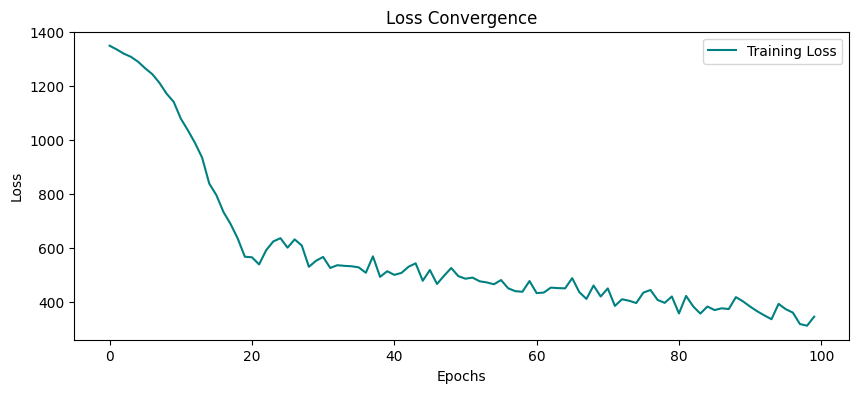

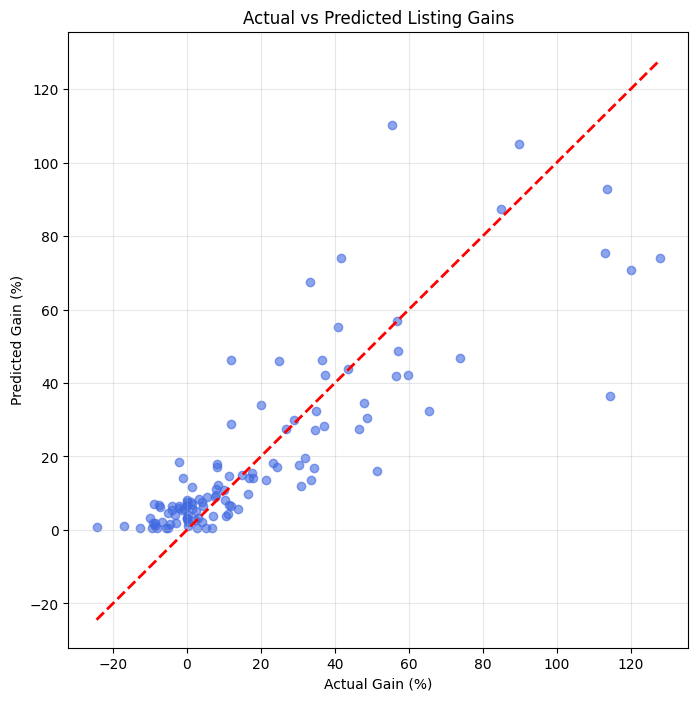

In [22]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss to ensure it hasn't plateaued too early
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='teal', label='Training Loss')
plt.title('Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2. Actual vs Predicted Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions.numpy(), alpha=0.6, color='royalblue')
# The red line represents a perfect 1:1 prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Listing Gains')
plt.xlabel('Actual Gain (%)')
plt.ylabel('Predicted Gain (%)')
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    nn_rmse = np.sqrt(mean_squared_error(y_test, predictions.numpy()))
    nn_r2 = r2_score(y_test, predictions.numpy())

print(f"--- Neural Network Results ---")
print(f"RMSE: {nn_rmse:.4f}")
print(f"R² Score: {nn_r2:.4f}")

print(f"\n--- Comparison ---")
print(f"Baseline RMSE: {baseline_rmse:.4f} vs NN RMSE: {nn_rmse:.4f}")

--- Neural Network Results ---
RMSE: 16.9053
R² Score: 0.6961

--- Comparison ---
Baseline RMSE: 17.6006 vs NN RMSE: 16.9053


In [20]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print("Training Complete!")

Epoch [10/100], Loss: 1141.1278
Epoch [20/100], Loss: 567.2401
Epoch [30/100], Loss: 552.1939
Epoch [40/100], Loss: 513.5166
Epoch [50/100], Loss: 495.2865
Epoch [60/100], Loss: 477.2213
Epoch [70/100], Loss: 419.9304
Epoch [80/100], Loss: 419.9182
Epoch [90/100], Loss: 401.7927
Epoch [100/100], Loss: 345.1453
Training Complete!


In [19]:
import torch.nn as nn
import torch.optim as optim

class IPONet(nn.Module):
    def __init__(self, input_size):
        super(IPONet, self).__init__()
        # Layer 1: Input to 64 neurons
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.2) # Regularization

        # Layer 2: 64 to 32 neurons
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2) # Regularization

        # Output Layer: 1 neuron (predicting the gain)
        self.output = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu2(self.fc2(x))
        x = self.dropout2(x)
        x = self.output(x)
        return x

# Initialize the model
input_dim = X_train_tensor.shape[1]
model = IPONet(input_dim)

# Define Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5) # weight_decay is L2 regularization

print("Neural Network Architecture Created!")

Neural Network Architecture Created!


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initialize and train the model
baseline_model = LinearRegression()

# Ensure X_train and X_test are free of NaN/inf values before fitting
# Replace NaN with 0, and infinite values with large finite numbers
X_train_cleaned = np.nan_to_num(X_train, nan=0.0, posinf=1e10, neginf=-1e10)
X_test_cleaned = np.nan_to_num(X_test, nan=0.0, posinf=1e10, neginf=-1e10)

baseline_model.fit(X_train_cleaned, y_train) # Using the scaled numpy arrays from Phase 2

# 2. Make predictions
y_pred_baseline = baseline_model.predict(X_test_cleaned) # Use the cleaned X_test

# 3. Evaluate
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"--- Baseline Linear Regression Results ---")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R² Score: {baseline_r2:.4f}")

--- Baseline Linear Regression Results ---
RMSE: 17.6006
R² Score: 0.6706


In [17]:
from sklearn.preprocessing import StandardScaler
import torch

scaler = StandardScaler()

# Fit the scaler on training data and transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert our data into PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(f"Ready! Training set size: {X_train_tensor.shape[0]} samples")

Ready! Training set size: 448 samples


In [16]:
from sklearn.model_selection import train_test_split

# X = Features (The data used to predict)
# y = Target (What we want to predict)
X = df_cleaned.drop('Listing Gain', axis=1).values
y = df_cleaned['Listing Gain'].values

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# 1. Remove symbols and convert to numbers
# We clean 'x' from subscription columns and '%' from gains
cols_to_clean_x = ['QIB', 'HNI', 'RII', 'Total']
for col in cols_to_clean_x:
    df[col] = df[col].astype(str).str.replace('x', '').astype(float)

# Clean '%' from Listing Gain and convert to float
df['Listing Gain'] = df['Listing Gain'].astype(str).str.replace('%', '').str.replace('+', '').astype(float)

# 2. Drop columns we don't need for prediction and those with too many missing values
# We don't need the Name or the current market price (CMP) to predict the listing day
df_cleaned = df.drop(['Date', 'IPO_Name', 'CMP(NSE)'], axis=1)

# Identify and drop columns that start with 'Unnamed' as they often contain junk data
unnamed_cols = [col for col in df_cleaned.columns if 'Unnamed' in col]
df_cleaned = df_cleaned.drop(columns=unnamed_cols, axis=1)

# 3. Handle any remaining missing values by filling them with the median
df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))

print("Data Cleaned! Here is the new structure:")
print(df_cleaned.head())

Data Cleaned! Here is the new structure:
   Issue_Size(crores)     QIB    HNI    RII   Total  Offer Price  List Price  \
0              650.00   36.72  38.24  32.55   36.20          385       386.0   
1              792.00  163.90  57.71  20.28   69.14          150       179.1   
2             4011.60  103.97  34.98   7.73   41.01          800       880.0   
3             1300.00  133.21  72.00  50.87  100.69          675      1018.0   
4              254.26    1.30   1.84   2.22    1.87          158       136.0   

   Listing Gain  CMP(BSE)  Current Gains  
0          0.26    426.85         10.870  
1         19.40    201.10         34.070  
2         10.00   1294.05         14.675  
3         50.81   1064.60         57.720  
4        -13.92    149.00         -5.700  


In [7]:
# You might need this library to read Excel files
!pip install openpyxl

import pandas as pd

# Load the Excel file
# Note: Make sure the filename below matches exactly what you uploaded
df = pd.read_excel('/content/sample_data/Initial Public Offering.xlsx')

# Show the first 5 rows to make sure it loaded correctly
df.head()

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,...,CMP(NSE),Current Gains,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,2025-08-06,M & B Engineering Ltd,650.00,36.72,38.24,32.55,36.20,385,386.0,0.26,...,426.15,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-06,Sri Lotus Developers & Realty Ltd,792.00,163.90,57.71,20.28,69.14,150,179.1,19.40,...,199.72,34.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-06,National Securities Depository Ltd (NSDL),4011.60,103.97,34.98,7.73,41.01,800,880.0,10.00,...,61.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-05,Aditya Infotech Ltd,1300.00,133.21,72.00,50.87,100.69,675,1018.0,50.81,...,1062.70,57.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-05,Laxmi India Finance Ltd,254.26,1.30,1.84,2.22,1.87,158,136.0,-13.92,...,150.00,-5.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
